In [186]:
# Code for reproducing wedges results in the paper Sanchez et al. 2016 
# "The clustering of galaxies in the completed SDSS-III Baryon Oscillation Spectroscopic Survey: 
# cosmological implications of the configuration-space clustering wedges"

In [187]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

In [188]:
# Reading data from the BOSS DR12 wedge files
file_path_1_1 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin1_correlation_function_3wedges1_pre_recon.dat'
file_path_1_2 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin1_correlation_function_3wedges2_pre_recon.dat'
file_path_1_3 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin1_correlation_function_3wedges3_pre_recon.dat'

file_path_2_1 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin2_correlation_function_3wedges1_pre_recon.dat'
file_path_2_2 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin2_correlation_function_3wedges2_pre_recon.dat'
file_path_2_3 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin2_correlation_function_3wedges3_pre_recon.dat'

file_path_3_1 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin3_correlation_function_3wedges1_pre_recon.dat'
file_path_3_2 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin3_correlation_function_3wedges2_pre_recon.dat'
file_path_3_3 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin3_correlation_function_3wedges3_pre_recon.dat'

In [189]:
# Getting an idea of the file structure, this operation will be carried for one file only
with open(file_path_1_1, 'r') as file:
    data = file.readlines()

# Printing the first 10 lines of the file
for line in data[:10]:
    print(line.strip())

#measurements of the pre-reconstruction configuration-space 3-wedges of the DR12 combined sample for 0.2 < z < 0.5
#from Sanchez et al. (2016)
#   s/(Mpc/h)          xi_3w,1       sigma xi_3w,1
0.250000000E+01   0.508129515E+01   0.335487226E-01
0.750000000E+01   0.175477649E+01   0.128133800E-01
0.125000000E+02   0.811639460E+00   0.853051586E-02
0.175000000E+02   0.450209654E+00   0.626564463E-02
0.225000000E+02   0.274348311E+00   0.502706081E-02
0.275000000E+02   0.183417946E+00   0.419071252E-02
0.325000000E+02   0.126147337E+00   0.366328175E-02


In [190]:
# Reading the file with pandas
df_1_1 = pd.read_csv(file_path_1_1, sep='\s+', skiprows=3, header=None)

# Manual column naming
df_1_1.columns = ['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1']

# Visualize the first few rows of the DataFrame
print(df_1_1.head())

# Check the shape of the DataFrame
print(df_1_1.shape)

# Check the column names
print(df_1_1.columns)

   s_Mpc_h   xi_3w_1  sigma_xi_3w_1
0      2.5  5.081295       0.033549
1      7.5  1.754776       0.012813
2     12.5  0.811639       0.008531
3     17.5  0.450210       0.006266
4     22.5  0.274348       0.005027
(32, 3)
Index(['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1'], dtype='object')


In [191]:
# Reading the files with pandas
df_1_2 = pd.read_csv(file_path_1_2, sep='\s+', skiprows=3, header=None)
df_1_3 = pd.read_csv(file_path_1_3, sep='\s+', skiprows=3, header=None)

df_2_1 = pd.read_csv(file_path_2_1, sep='\s+', skiprows=3, header=None)
df_2_2 = pd.read_csv(file_path_2_2, sep='\s+', skiprows=3, header=None)
df_2_3 = pd.read_csv(file_path_2_3, sep='\s+', skiprows=3, header=None)

df_3_1 = pd.read_csv(file_path_3_1, sep='\s+', skiprows=3, header=None)
df_3_2 = pd.read_csv(file_path_3_2, sep='\s+', skiprows=3, header=None)
df_3_3 = pd.read_csv(file_path_3_3, sep='\s+', skiprows=3, header=None)

# Manual column naming
df_1_2.columns = ['s_Mpc_h', 'xi_3w_2', 'sigma_xi_3w_2']
df_1_3.columns = ['s_Mpc_h', 'xi_3w_3', 'sigma_xi_3w_3']

df_2_1.columns = ['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1']
df_2_2.columns = ['s_Mpc_h', 'xi_3w_2', 'sigma_xi_3w_2']
df_2_3.columns = ['s_Mpc_h', 'xi_3w_3', 'sigma_xi_3w_3']

df_3_1.columns = ['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1']
df_3_2.columns = ['s_Mpc_h', 'xi_3w_2', 'sigma_xi_3w_2']
df_3_3.columns = ['s_Mpc_h', 'xi_3w_3', 'sigma_xi_3w_3']


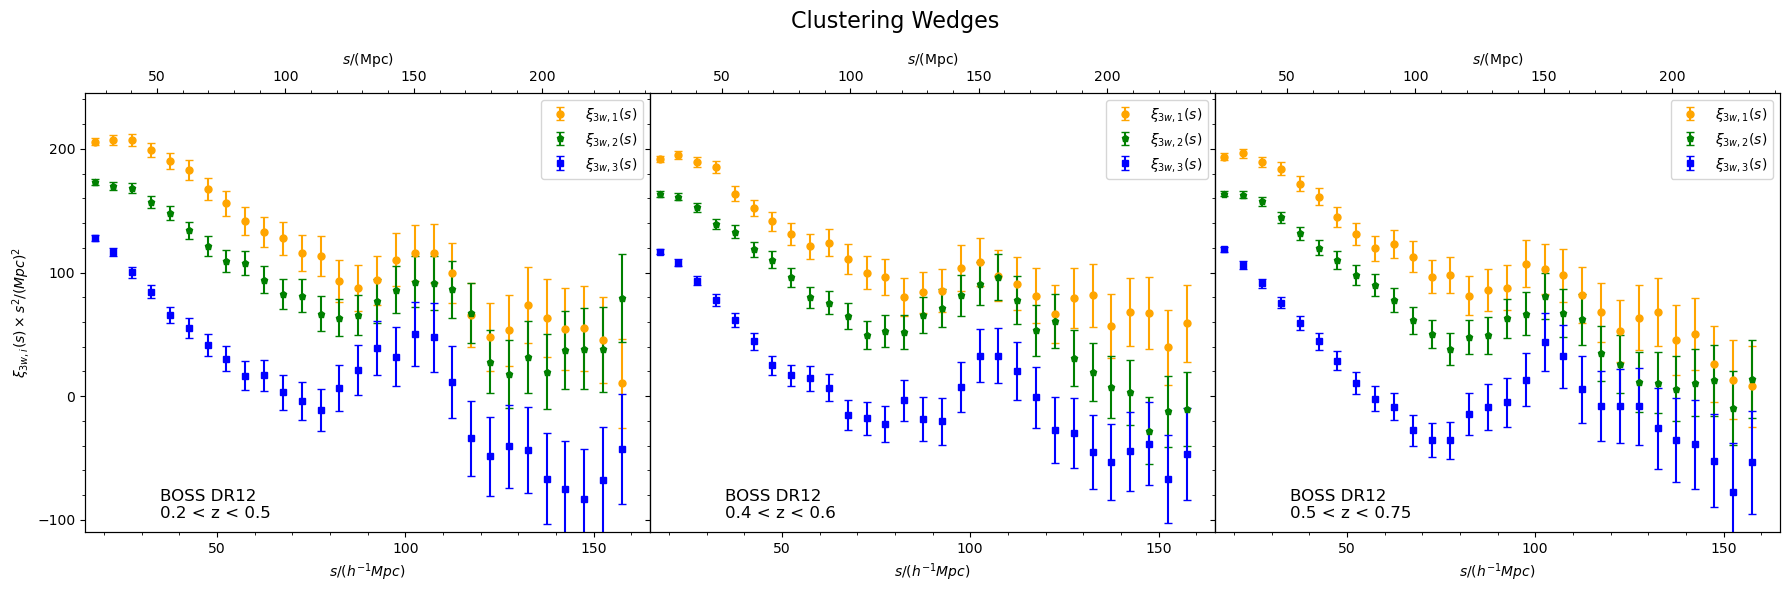

In [193]:
# Wedges plot
dataframes = [df_1_1, df_1_2, df_1_3, df_2_1, df_2_2, df_2_3, df_3_1, df_3_2, df_3_3]

# Layout of 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True, gridspec_kw={'wspace': 0, 'width_ratios': [1, 1, 1]})

# Aggiunta di un titolo a tutta la figura
fig.suptitle("Clustering Wedges", fontsize=16)

# Colors, labels and z_ranges
colors = ['orange', 'green', 'blue']
labels = [r'$\xi_{3w,1}(s)$', r'$\xi_{3w,2}(s)$', r'$\xi_{3w,3}(s)$']
z_ranges = ["0.2 < z < 0.5", "0.4 < z < 0.6", "0.5 < z < 0.75"]

h = 0.67

# Iterate over the subplots (one for each redshift range)
for i, ax in enumerate(axs):
    # Plot of the 3 DataFrame for each subplot
    for j in range(3):
        # Obtain the corrspondent DataFrame
        df = dataframes[i * 3 + j]
        
        # Assign data (column 1: x, column 2: y, column 3: error over y)
        x = df.iloc[:, 0]
        y = df.iloc[:, 1]
        yerr = df.iloc[:, 2]
        
        # Plot with error bars
        ax.errorbar(x, y*x**2/h, yerr=yerr*x**2/h, fmt='o' if colors[j] == 'orange' else 's' if colors[j] == 'blue' else 'p', color=colors[j], label=labels[j], markersize=5, capsize=3)

    
    # Axis limits
    #ax.set_xlim(30, 240)      
    ax.set_ylim(-110, 245)     

    # Top axis
    #ax_top = ax.twiny()
    ax.set_xlim(15, 165)  # Limiti asse superiore
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.set_xlabel(r"$s/(h^{-1} \, \mathrm{Mpc})$")
    # Limiti dell'asse x superiore (valori originali)
    ax_top = ax.twiny()
    ax_top.set_xlim(22, 242)
    ax_top.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax_top.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    #ax.set_xlabel(r"$s/(h^{-1} \, \mathrm{Mpc})$")
    
    # Aggiungi asse x inferiore con valori scalati
    #h = 0.67
    #ax_bottom = ax.twiny()
    #ax_bottom.set_xlim(22, 242)  # Limiti asse inferiore scalati
    #ax_bottom.xaxis.set_major_locator(ticker.MultipleLocator(50))
    #ax_bottom.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    #ax_bottom.set_xticks(x)  # Tick nei punti originali
    #ax_bottom.set_xticklabels([f"{val * h:.1f}" for val in x])  # Etichette scalate

    # Etichetta per l'asse inferiore
    ax_top.set_xlabel(r"$s/(\mathrm{Mpc})$")

    ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
    
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    
    # Titles and labels
    # Aggiungi testo all'interno del grafico per BOSS e il range di redshift
    ax.text(35, -75, f"BOSS DR12\n{z_ranges[i]}", fontsize=12, ha='left', va='top', bbox=dict(facecolor='white', alpha=0.))

    # Rimuovi gli spazi tra i grafici
    plt.subplots_adjust(wspace=0)
    ax.set_xlabel(r"$s/(h^{-1}Mpc)$")
    ax.legend(loc='upper right')
    #ax.grid(True)

    axs[0].set_ylabel(r"$\xi_{3w,i}(s) \times s^2/(Mpc)^2$")

    plt.tight_layout()
    #plt.show()